# Part C Dissertation - Modelling Networks with Complex Weights
## Nested RGM Generator
#### _(Candidate 1509403)_

In this notebook, we introduce the nested RGM. We write functions to generate the random graph model, using it to understand how our perturbation assumptions break down and how exactly this happens. 

For a detailed explanation of how the nested RGM is set up, find Subsection 3.4.1 of the dissertation.

In the dissertation, we are interested in the results of $\lambda_1$ at $r$ where at $t=0$ we are at structural balance. That is, we have $\lambda_1 = 0$. For this reason, we chose to look at $n=120$, because $n$ here is large enough that we our small perturbation theory assumption applies. Furthermore, $n=120$ has lots of nice factors, so we have lots of $r$ values to choose from.

We directly calculate the mean and standard deviation of $\lambda_1$ for each $r$ value of interest. We then create the accompanying plots at the end of this notebook.

In [1]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import scipy.special as sp
import pickle
import os
rng = np.random.default_rng(seed=None)

In [2]:
def mLapN(M, theta):
    M = M.toarray()
    n = np.shape(M)[0]
    #defines unweighted symmetric matrix
    W_s = (M + M.T) / 2

    #directional info matrix
    A = M
    A[(M > 0) & (M.T == 0)] = 1
    A[(M == 0) & (M.T > 0)] = -1
        
    #T matrix
    T = np.exp(1j * theta * A)
    #L matrix
    L = -W_s * T
    np.fill_diagonal(L, np.sum(W_s, axis=1))

    #Normalisation step, sets L_N = D^(-1/2) * L * D^(-1/2)
    D = np.sum(W_s, axis=1)
    normD = 1 / np.sqrt(D)
    L_N = (normD[:, None] * L) * normD[None, :]
    
    return L_N

In [3]:
#function to create a new edge, occurs each timestep
def newEdgeNest(G, n, startNode, length):
    if n == None:
        n = G.number_of_nodes()

    if startNode + length > n:
        endNode = startNode + length - n
    elif startNode + length < 1:
        endNode = startNode + length + n
    else:
        endNode = startNode + length
    #note that we cannot have a chord of length > n
    
    G.add_edge(startNode, endNode) #adds edge to the target afterwards
    return G

In [4]:
#function to generate a nested graph with chords of fixed length
def nestRandGen(G, edges, length):
    n = G.number_of_nodes()
    nodeList = np.arange(1, n+1)
    np.random.shuffle(nodeList) #defines a random list of the nodes, we add nested edges in order of the list
    for i in range(0, edges):
        newEdgeNest(G, n, nodeList[i], length) #simulates adding [edges] edges to the model
    return G

In [5]:
def nestRandSims(G, edges, length, rValues, eigInterest, sims):
    n = G.number_of_nodes()
    nodeList = np.arange(1, n+1)
    
    #eigArrayFull = np.zeros(sims) #gives eigenvalues
    #eigDiffFull = np.zeros(sims) #gives difference in eigenvalue at each timestep, we use this to find big jumps
    eigArrayFull = {} #gives eigenvalues
    eigDiffFull = {} #gives difference in eigenvalue at each timestep, we use this to find big jumps

    for k in range(0, sims):
        Gcopy = G.copy()
        eigArray = {} #gives eigenvalues
        eigDiff = {} #gives difference in eigenvalue at each timestep, we use this to find big jumps
        np.random.shuffle(nodeList) #randomly shuffles nodeList each time
        #populates array with eigenvalues for C_n
        for r in rValues:
            eigArray[r] = np.zeros((edges+1, len(eigInterest)))
            eigDiff[r] = np.zeros((edges+1, len(eigInterest)))
            A = nx.adjacency_matrix(Gcopy)
            L_N = mLapN(A, (2*np.pi)/r)
            eigs = np.linalg.eigvalsh(L_N)
            for eigToSave in eigInterest:
                eigArray[r][0] = eigs[eigToSave - 1]
                eigDiff[r][0] = eigArray[r][0]
    
        for i in range(0, edges):
            newEdgeNest(Gcopy, n, nodeList[i], length)
            A = nx.adjacency_matrix(Gcopy)
            for r in rValues:
                L_N = mLapN(A, (2*np.pi)/r)
                eigs = np.linalg.eigvalsh(L_N)
                for eigToSave in eigInterest:
                    eigArray[r][i+1] = eigs[eigToSave - 1]
                    eigDiff[r][i+1] = eigArray[r][i+1] - eigArray[r][i]

        eigArrayFull[k] = eigArray
        eigDiffFull[k] = eigDiff
    return eigArrayFull, eigDiffFull

In [6]:
def DiCycle(n):
    C_n = nx.cycle_graph(n, create_using=nx.DiGraph())
    C_n = nx.relabel_nodes(C_n, {0: n})
    return C_n

In [7]:
n = 120
Cn = DiCycle(n)
edges = n
length = 2
rValues = [1, 2, 3, 4, 5, 6, 10, 20, 24, 30, 40, 58, 59, 60, 61, 62]
eigInterest = [1]
sims = 1000
eigArrayFull, eigDiffFull = nestRandSims(Cn, edges, length, rValues, eigInterest, sims)

In [8]:
means = {}
stds = {}
med = {}
lower = {}
upper = {}

for r in rValues:
    means[r] = []
    stds[r] = []
    med[r] = []
    for i in range(0, edges+1):
        eigValues = []
        for k in range(0, sims):
            eigValues.append(eigArrayFull[k][r][i])
        means[r].append(np.nanmean(eigValues))
        stds[r].append(np.nanstd(eigValues))
        med[r].append(np.nanmedian(eigValues))
        
    means[r] = np.array(means[r])
    stds[r] = np.array(stds[r])
    med[r] = np.array(med[r])

    lower[r] = means[r] - stds[r]
    upper[r] = means[r] + stds[r]

### Below are the exact results of Table 3.1.
Note that these may not exactly match up: we know that standard deviation at $t=0$ and $t=120$ must be zero (any differences here are floating point inaccuracies). Similarly, at $t=0$ we know that $\lambda_1 = 0$. Any differences here are again floating point inaccuracies. 

In [9]:
rValues = [2, 3, 4, 5, 6, 10, 20, 24, 30, 40, 60]
tValues = [0, 1, 10, 20, 60, 120]
for r in rValues:
    print(r)
    print([means[r][t] for t in tValues])

2
[-1.0397425766463883e-15, 0.00034845608938101433, 0.005218857723528607, 0.014730239539649479, 0.11074528151387679, 0.4375777755565202]
3
[6.375108749673202e-17, 0.0003426671932167057, 0.00504739392159201, 0.01396028099066212, 0.0920111190508371, 0.20866196799926895]
4
[-5.442694905877232e-17, 0.0003315180910071568, 0.004731094144001916, 0.012614597243237836, 0.0685029976680864, 0.11996324466495029]
5
[-1.704365820715235e-16, 0.0003174215910743811, 0.004357269758593704, 0.011130816759037184, 0.05083602490941085, 0.07791349774087776]
6
[9.15066628009743e-17, 0.0003012774486787043, 0.003963367280850517, 0.009698736428592036, 0.0385134211008421, 0.05415347081179689]
10
[-2.846213173211271e-16, 0.00022942511476977193, 0.0026079876093754568, 0.005571140877443512, 0.015907077376101884, 0.019776139171329234]
20
[-2.5153490404450514e-17, 0.00010382407610951576, 0.0010997666923770542, 0.002034896877822798, 0.0045274894228518525, 0.005478104631726573]
24
[3.924811864397526e-17, 7.81301082111826

In [10]:
for r in rValues:
    print(r)
    print([stds[r][t] for t in tValues])

2
[0.0, 4.1410402333204683e-16, 0.002644164220672521, 0.00694490927577599, 0.04045826370446975, 1.6653345369377348e-16]
3
[1.232595164407831e-32, 5.567126431479579e-16, 0.002500296464490329, 0.006313845690478866, 0.027414161275643816, 0.0]
4
[0.0, 2.558882396749488e-16, 0.002234844436221728, 0.0052654579283370265, 0.015228413450799632, 5.551115123125783e-17]
5
[4.930380657631324e-32, 2.0464076228281638e-16, 0.0019294373772700628, 0.004195634106358922, 0.008487621237214185, 1.3877787807814457e-17]
6
[2.465190328815662e-32, 2.1368651939248568e-16, 0.0016234891049099656, 0.0032661249617638353, 0.0049759149053492146, 6.938893903907228e-18]
10
[4.930380657631324e-32, 2.1267472048509276e-16, 0.0007583453465136395, 0.0012165049112424797, 0.0009941316265125089, 0.0]
20
[9.244463733058732e-33, 2.0847168634453083e-16, 0.00015558018490122806, 0.00020783239855256047, 0.00012623110297033888, 1.734723475976807e-18]
24
[0.0, 1.9888236476588478e-16, 8.757627942129841e-05, 0.00014619731813258365, 0.000

### The plots below populate the figures in Subsection 3.4.1.

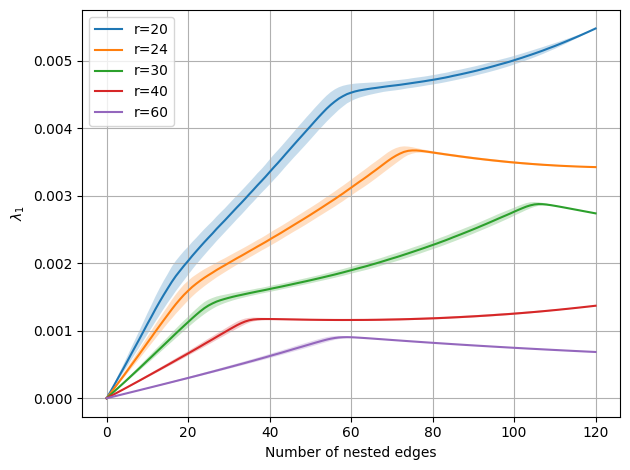

In [27]:
x = np.linspace(0, 120, 121)
#rValues = [2,3,4,5,6,22, 23, 24, 25, 26, 20, 30, 40, 60]
rValues = [20, 24, 30, 40, 60]
for r in rValues:
    plt.plot(x, means[r], label=f"r={r}")
    #plt.plot(x, med[r], label=f"median, r={r}")
    plt.fill_between(x, lower[r], upper[r], alpha=0.25) #, label='±1 std dev')
plt.xlabel("Number of nested edges")
plt.ylabel("$\lambda_1$")
#plt.title(f"$\lambda_1$ against number of nested edges, r={r}, {sims} realisations")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()